### Métodos Numéricos Computacionales
#### Prácticas computacionales de "Solución de ecuaciones diferenciales ordinarias"

Instrucciones para los Ejercicios

1. **Trabajo en Grupo:**
   - Los ejercicios deben ser resueltos y entregados en grupo.
   - La cantidad de integrantes por grupo será definida el día de la actividad, así como la fecha límite para la entrega.

2. **Uso de Google Colab y Compartir:**
   - Este notebook debe ser copiado al GitHub o Google Drive de alguno de los integrantes del grupo.
   - El grupo será responsable de programar las soluciones, realizar las pruebas y enviar el trabajo final al profesor.

3. **Implementación de los Ejercicios:**
   - Cada ejercicio debe ser implementado de manera que cumpla con los objetivos específicos descritos en cada problema.
   - El código debe devolver claramente la información calculada de acuerdo a lo solicitado.

4. **Calidad del Código:**
   - El código debe ejecutarse sin errores.
   - Es obligatorio incluir **comentarios explicativos** para describir las ideas y conceptos implícitos en el código, facilitando la comprensión de su lógica.

5. **Envío del Trabajo:**
   - Una vez completado, el notebook debe ser enviado a través de Moodle.
   - En caso de dudas, pueden contactarme por correo electrónico a **marcelo.danesi@utec.edu.uy**.

6. **Orientaciones Adicionales:**
   - Asegúrense de que todas las celdas de código hayan sido ejecutadas antes de enviar.
   - Incluyan el nombre completo y correo electrónico de todos los integrantes al inicio del notebook.
   - Si utilizan referencias externas, menciónenlas de forma adecuada.

¡Buena suerte y aprovechen la práctica para consolidar los conceptos de métodos numéricos!

En esta práctica trabajaremos con problemas de valor inicial (PVI) para ecuaciones diferenciales ordinarias de primer orden de la forma:
$$
y' = f(x, y), \quad y(x_0) = y_0
$$

Este tipo de problemas aparece con frecuencia en modelos físicos, químicos, biológicos y económicos. Como en muchos casos no es posible encontrar soluciones analíticas exactas, recurrimos a técnicas numéricas para obtener aproximaciones.

A lo largo de esta notebook exploraremos los métodos más comunes para resolver PVI:
- Método de Euler.
- Método de Runge-Kutta de cuarto orden (RK4).
- Método de Euler implícito.
- Fórmulas de Diferenciación Regresiva (BDF).

Cada técnica será acompañada por un ejemplo programado, seguido por ejercicios de implementación y comparación de resultados.


#### **Métodos explícitos: Método de Euler**

Es el método más sencillo para aproximar una solución numérica. A partir del valor conocido $y_n$, se calcula el siguiente valor $y_{n+1}$ como:
$$
y_{n+1} = y_n + h f(x_n, y_n)
$$

##### **Ejemplo: Implementación del Método de Euler**

**Descripción del problema:**

Resolver el PVI
$$
\left\{ \begin{array}{l}
y' =  x - y, \\
y(0) = 3.
\end{array} \right.
$$

en el intervalo $x\in [0, 2.5]$ con paso $h = 0.5$.

**Objetivos:**

- Implementar el método de Euler.
- Calcular $y$ en varios puntos.
- Visualizar la trayectoria aproximada.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función que implementa el método de Euler explícito
def euler(f, x0, y0, h, n):
    x = [x0]      # Lista de valores de x
    y = [y0]      # Lista de valores de y
    for i in range(n):
        y_new = y[-1] + h * f(x[-1], y[-1])  # Aproximación de y en el siguiente paso
        x_new = x[-1] + h                    # Avance en x
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# Definimos la función del PVI: y' = x - y
f = lambda x, y: x - y

# Ejecutamos la función con condiciones iniciales
x, y = euler(f, 0, 3, 0.5, 5)

# Graficamos el resultado
plt.plot(x, y, 'o-', label='Euler')
plt.title("Método de Euler")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

##### **Ejercicio 1: Primeros pasos con Euler**

**Descripción del problema:**  
Aproxime la solución del siguiente PVI usando el método de Euler con paso $h = 0.2$:
$$
y' = x + y, \quad y(0) = 1.
$$

**Objetivos:**
- Aplicar el método de Euler paso a paso.
- Calcular los valores aproximados de $y$ para $x = 0, 0.2, 0.4, 0.6, 0.8, 1.0$.
- Graficar la solución aproximada.

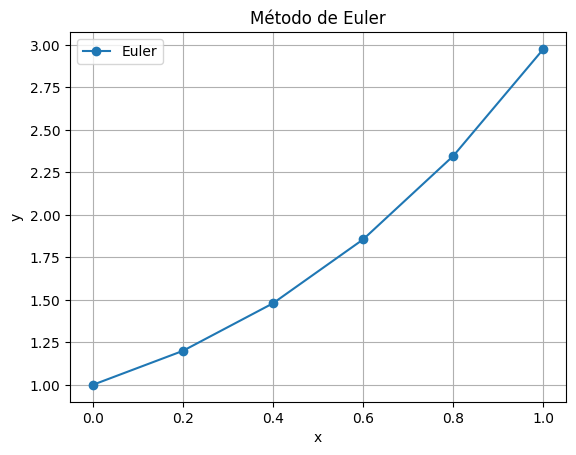

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función que implementa el método de Euler explícito
def euler(f, x0, y0, h, n):
    x = [x0]      # Lista de valores de x
    y = [y0]      # Lista de valores de y
    for i in range(n):
        y_new = y[-1] + h * f(x[-1], y[-1])  # Aproximación de y en el siguiente paso
        x_new = x[-1] + h                    # Avance en x
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# Definimos la función del PVI: y' = x - y
f = lambda x, y: x + y

# Ejecutamos la función con condiciones iniciales
x, y = euler(f, 0, 1, 0.2, 5)

# Graficamos el resultado
plt.plot(x, y, 'o-', label='Euler')
plt.title("Método de Euler")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

##### **Ejercicio 2: Comparación con solución exacta**

**Descripción del problema:**  
Considere el PVI:
$$
y' = x - 2y, \quad y(0) = 1.
$$
Use el método de Euler con $h = 0.1$ hasta $x = 1$.

**Objetivos:**
- Comparar la solución numérica con la solución analítica $y(x) = \frac{1}{4}(2x - 1 +5e^{-2x})$.
- Graficar ambas soluciones.
- Calcular el error absoluto en cada punto.


Comparación de Resultados (Método de Euler vs. Solución Analítica):
x          Euler (y)       Analítica (y)      Error Absoluto    
-------------------------------------------------------------
0.0000     1.000000        1.000000           0.000000          
0.1000     0.800000        0.823413           0.023413          
0.2000     0.650000        0.687900           0.037900          
0.3000     0.540000        0.586015           0.046015          
0.4000     0.462000        0.511661           0.049661          
0.5000     0.409600        0.459849           0.050249          
0.6000     0.377680        0.426493           0.048813          
0.7000     0.362144        0.408246           0.046102          
0.8000     0.359715        0.402371           0.042655          
0.9000     0.367772        0.406624           0.038851          
1.0000     0.384218        0.419169           0.034951          


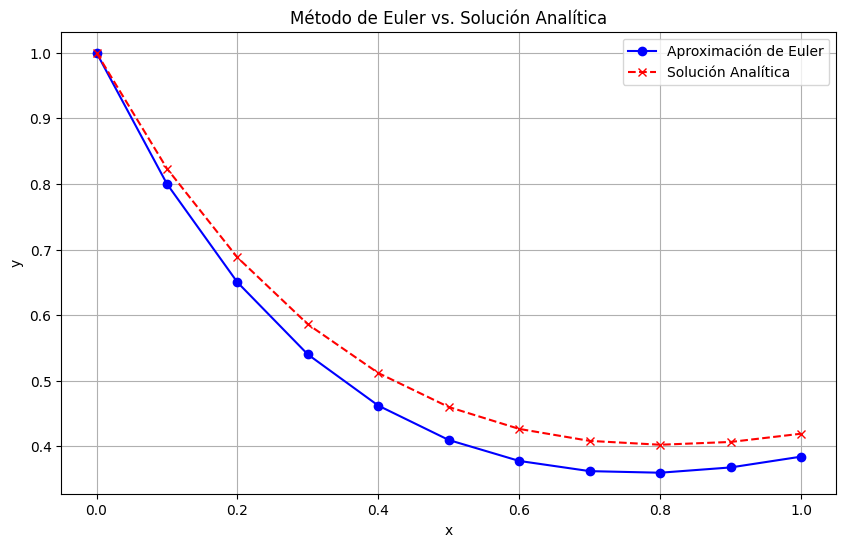

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función que implementa el método de Euler explícito
def euler(f, x0, y0, h, n):
    """
    Implementa el método de Euler explícito para resolver un PVI.

    Args:
        f (function): La función f(x, y) que define la EDO y' = f(x, y).
        x0 (float): El valor inicial de x.
        y0 (float): El valor inicial de y.
        h (float): El tamaño del paso (incremento en x).
        n (int): El número de pasos a realizar.

    Returns:
        tuple: Dos arreglos de NumPy (x_values, y_values) con los puntos calculados.
    """
    x = [x0]      # Lista de valores de x
    y = [y0]      # Lista de valores de y
    for i in range(n):
        y_new = y[-1] + h * f(x[-1], y[-1])  # Aproximación de y en el siguiente paso
        x_new = x[-1] + h                    # Avance en x
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# Definimos la función del PVI: y' = x -2*y
f = lambda x, y: x -2*y

# Definimos la solución analítica del PVI: y(x) = 1/4 * (2x - 1 + 5e^(-2x))
def solucion_analitica(x):
    """
    Calcula el valor de la solución analítica y(x) = 1/4 * (2x - 1 + 5e^(-2x)).

    Args:
        x (float or np.array): El valor o arreglo de valores de x.

    Returns:
        float or np.array: El valor o arreglo de valores de y(x).
    """
    return (1/4) * (2 * x - 1 + 5 * np.exp(-2 * x))

# Condiciones iniciales
x0 = 0
y0 = 1
h = 0.1
n = 10

# Ejecutamos la función de Euler con las condiciones iniciales
x_euler, y_euler = euler(f, x0, y0, h, n)

# Calculamos la solución analítica para los mismos puntos x_euler
y_analitica = solucion_analitica(x_euler)

# Imprimimos los resultados para comparación
print("Comparación de Resultados (Método de Euler vs. Solución Analítica):")
print(f"{'x':<10} {'Euler (y)':<15} {'Analítica (y)':<18} {'Error Absoluto':<18}")
print("-" * 61)
for i in range(len(x_euler)):
    error_abs = abs(y_euler[i] - y_analitica[i])
    print(f"{x_euler[i]:<10.4f} {y_euler[i]:<15.6f} {y_analitica[i]:<18.6f} {error_abs:<18.6f}")

# Graficamos los resultados
plt.figure(figsize=(10, 6)) # Aumentamos el tamaño de la figura para mejor visualización
plt.plot(x_euler, y_euler, 'o-', label='Aproximación de Euler', color='blue')
plt.plot(x_euler, y_analitica, 'x--', label='Solución Analítica', color='red')

plt.title("Método de Euler vs. Solución Analítica")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


##### **Ejercicio 3: Error en función del paso**

**Descripción del problema:**  
Resuelva numéricamente el siguiente PVI:
$$
y' = y - x^2 + 1, \quad y(0) = 0.5.
$$

**Objetivos:**
- Ejecutar el método de Euler con distintos valores de $h: 0.4, 0.2, 0.1, 0.05$ hasta $x = 2$.
- Comparar con la solución exacta $y(x) = (x + 1)^2 - 0.5e^x$.
- Graficar el error absoluto en función de $h$.


Comparación de Resultados (Método de Euler vs. Solución Analítica):
x          Euler (y)       Analítica (y)      Error Absoluto    
-------------------------------------------------------------
0.0000     0.500000        1.500000           1.000000          
0.4000     1.100000        2.705912           1.605912          
0.8000     1.876000        4.352770           2.476770          
1.2000     2.770400        6.500058           3.729658          
1.6000     3.702560        9.236516           5.533956          
2.0000     4.559584        12.694528          8.134944          


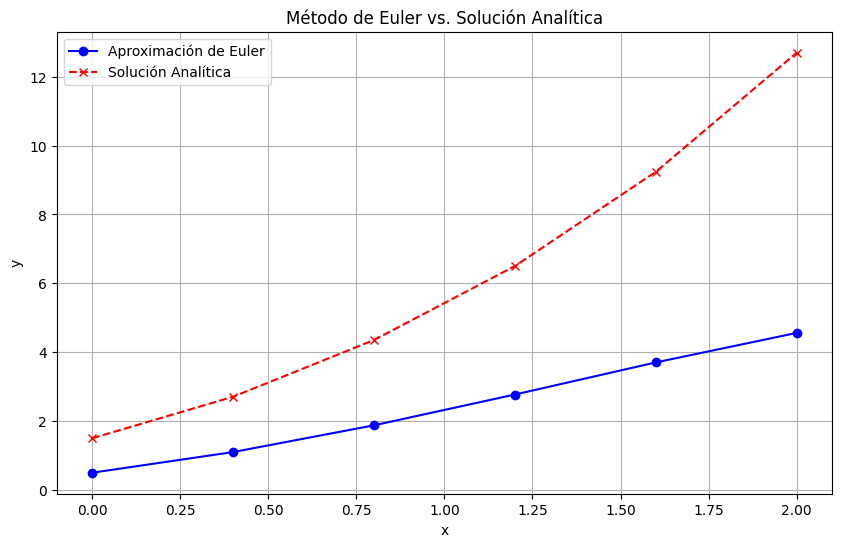

Comparación de Resultados (Método de Euler vs. Solución Analítica):
x          Euler (y)       Analítica (y)      Error Absoluto    
-------------------------------------------------------------
0.0000     0.500000        1.500000           1.000000          
0.2000     0.800000        2.050701           1.250701          
0.4000     1.152000        2.705912           1.553912          
0.6000     1.550400        3.471059           1.920659          
0.8000     1.988480        4.352770           2.364290          
1.0000     2.458176        5.359141           2.900965          
1.2000     2.949811        6.500058           3.550247          
1.4000     3.451773        7.787600           4.335827          
1.6000     3.950128        9.236516           5.286388          
1.8000     4.428154        10.864824          6.436670          
2.0000     4.865785        12.694528          7.828744          


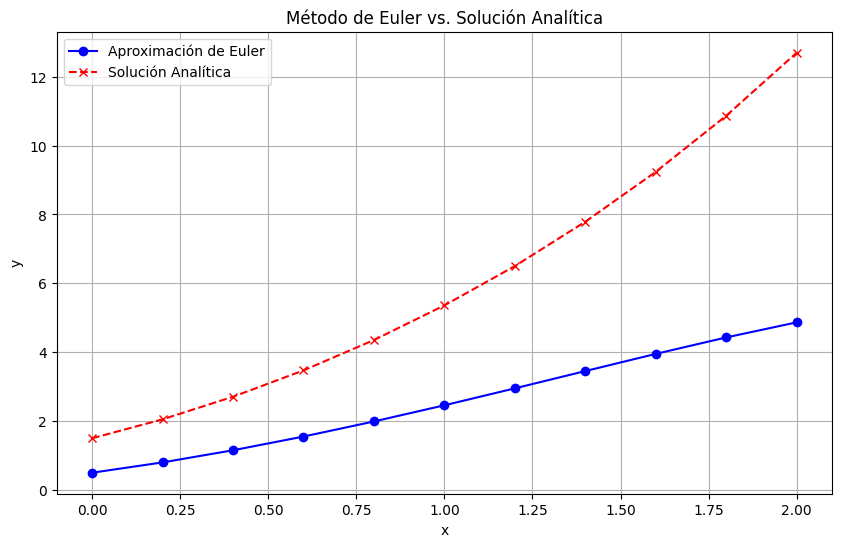

Comparación de Resultados (Método de Euler vs. Solución Analítica):
x          Euler (y)       Analítica (y)      Error Absoluto    
-------------------------------------------------------------
0.0000     0.500000        1.500000           1.000000          
0.1000     0.650000        1.762585           1.112585          
0.2000     0.814000        2.050701           1.236701          
0.3000     0.991400        2.364929           1.373529          
0.4000     1.181540        2.705912           1.524372          
0.5000     1.383694        3.074361           1.690667          
0.6000     1.597063        3.471059           1.873996          
0.7000     1.820770        3.896876           2.076107          
0.8000     2.053847        4.352770           2.298924          
0.9000     2.295231        4.839802           2.544570          
1.0000     2.543755        5.359141           2.815386          
1.1000     2.798130        5.912083           3.113953          
1.2000     3.056943      

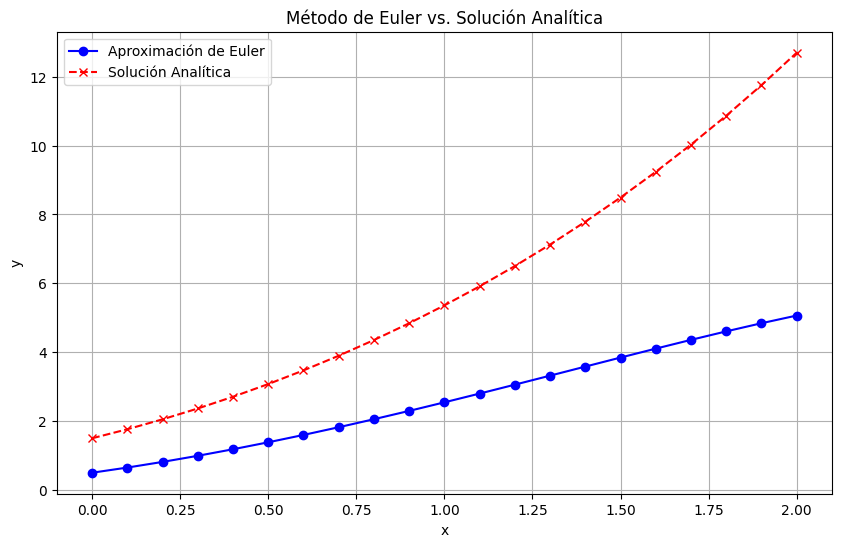

Comparación de Resultados (Método de Euler vs. Solución Analítica):
x          Euler (y)       Analítica (y)      Error Absoluto    
-------------------------------------------------------------
0.0000     0.500000        1.500000           1.000000          
0.0500     0.575000        1.628136           1.053136          
0.1000     0.653625        1.762585           1.108960          
0.1500     0.735806        1.903417           1.167611          
0.2000     0.821472        2.050701           1.229230          
0.2500     0.910545        2.204513           1.293968          
0.3000     1.002947        2.364929           1.361982          
0.3500     1.098595        2.532034           1.433439          
0.4000     1.197400        2.705912           1.508513          
0.4500     1.299269        2.886656           1.587387          
0.5000     1.404108        3.074361           1.670253          
0.5500     1.511813        3.269127           1.757313          
0.6000     1.622279      

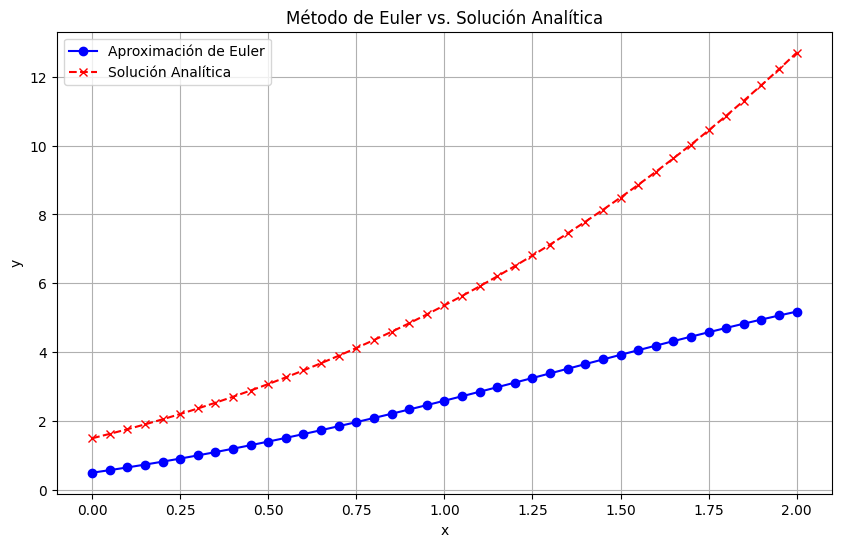

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Función que implementa el método de Euler explícito
def euler(f, x0, y0, h, n):
    """
    Implementa el método de Euler explícito para resolver un PVI.

    Args:
        f (function): La función f(x, y) que define la EDO y' = f(x, y).
        x0 (float): El valor inicial de x.
        y0 (float): El valor inicial de y.
        h (float): El tamaño del paso (incremento en x).
        n (int): El número de pasos a realizar.

    Returns:
        tuple: Dos arreglos de NumPy (x_values, y_values) con los puntos calculados.
    """
    x = [x0]      # Lista de valores de x
    y = [y0]      # Lista de valores de y
    for i in range(n):
        y_new = y[-1] + h * f(x[-1], y[-1])  # Aproximación de y en el siguiente paso
        x_new = x[-1] + h                    # Avance en x
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# Definimos la función del PVI: y' = x + y
f = lambda x, y: y-x*x+1

# Definimos la solución analítica del PVI: y(x) = 1/4 * (2x - 1 + 5e^(-2x))
def solucion_analitica(x):
    """
    Calcula el valor de la solución analítica y(x) = (x+1)^2 + 0.5*e^x.

    Args:
        x (float or np.array): El valor o arreglo de valores de x.

    Returns:
        float or np.array: El valor o arreglo de valores de y(x).
    """
    return (x+1)**2 + 0.5 * np.exp(x)

# Condiciones iniciales
x0 = 0
xf = 2
y0 = 0.5
lista_h = [0.4, 0.2, 0.1, 0.05]
for h in lista_h:
   n = math.ceil((xf-x0) * (1/h ))
   # Ejecutamos la función de Euler con las condiciones iniciales
   x_euler, y_euler = euler(f, x0, y0, h, n)

   # Calculamos la solución analítica para los mismos puntos x_euler
   y_analitica = solucion_analitica(x_euler)

   # Imprimimos los resultados para comparación
   print("Comparación de Resultados (Método de Euler vs. Solución Analítica):")
   print(f"{'x':<10} {'Euler (y)':<15} {'Analítica (y)':<18} {'Error Absoluto':<18}")
   print("-" * 61)
   for i in range(len(x_euler)):
      error_abs = abs(y_euler[i] - y_analitica[i])
      print(f"{x_euler[i]:<10.4f} {y_euler[i]:<15.6f} {y_analitica[i]:<18.6f} {error_abs:<18.6f}")

   # Graficamos los resultados
   plt.figure(figsize=(10, 6)) # Aumentamos el tamaño de la figura para mejor visualización
   plt.plot(x_euler, y_euler, 'o-', label='Aproximación de Euler', color='blue')
   plt.plot(x_euler, y_analitica, 'x--', label='Solución Analítica', color='red')

   plt.title("Método de Euler vs. Solución Analítica")
   plt.xlabel("x")
   plt.ylabel("y")
   plt.legend()
   plt.grid(True)
   plt.show()

#### **Métodos explícitos: Método de Runge-Kutta de cuarto orden (RK4)**

Este método mejora la precisión del método de Euler sin requerir pasos muy pequeños. Usa una media ponderada de varias pendientes intermedias para avanzar:


##### **Ejemplo: Implementación del Método de Runge-Kutta de cuarto orden (RK4)**

**Descripción del problema:**

Resolver el mismo PVI anterior
$$
\left\{ \begin{array}{l}
y' =  x - y, \\
y(0) = 3,
\end{array} \right.
$$

con $h = 0.5$ y comparar los resultados con el método de Euler.

**Objetivos:**
- Implementar el método de Runge-Kutta de cuarto orden.
- Calcular la solución numérica.
- Graficar la evolución de la solución.

In [ ]:
# Función que implementa el método RK4
def rk4(f, x0, y0, h, n):
    x = [x0]
    y = [y0]
    for i in range(n):
        k1 = f(x[-1], y[-1])
        k2 = f(x[-1] + h/2, y[-1] + h/2*k1)
        k3 = f(x[-1] + h/2, y[-1] + h/2*k2)
        k4 = f(x[-1] + h, y[-1] + h*k3)
        y_new = y[-1] + h/6*(k1 + 2*k2 + 2*k3 + k4)  # Fórmula de RK4
        x_new = x[-1] + h
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# Ejecutamos RK4 con el mismo problema
x, y = rk4(f, 0, 3, 0.5, 5)
plt.plot(x, y, 'o-', label='RK4')
plt.title("Método de Runge-Kutta 4")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

##### **Ejercicio 1: Aplicación básica del método RK4**

**Descripción del problema:**  
Resuelva el siguiente PVI usando RK4 con paso $h=0.2$:
$$
y' = x + y, \quad y(0) = 1.
$$

**Objetivos:**
- Implementar RK4 reutilizando la función ya desarrollada.
- Calcular $y$ para $x = 0, 0.2, 0.4, ..., 1.0$.
- Graficar la solución aproximada.

##### **Ejercicio 2: Comparación con método de Euler**

**Descripción del problema:**  
Considere el PVI:
$$
y' = y - x^2 + 1, \quad y(0) = 0.5.
$$

**Objetivos:**
- Comparar las soluciones obtenidas por RK4 y Euler con $h = 0.1$ hasta $x=2$.
- Comparar con la solución exacta $y(x) = (x + 1)^2 - 0.5e^x$.
- Graficar y analizar el error absoluto de cada método.

##### **Ejercicio 3: Aproximación y visualización**

**Descripción del problema:**  
Aproxime la solución del PVI:
$$
y' = \cos(x) - y, \quad y(0) = 0.
$$

**Objetivos:**
- Aplicar RK4 con $h = 0.1$ hasta $x = 3$.
- Graficar la trayectoria numérica.
- Estimar visualmente la convergencia hacia la solución exacta $$y(x) = \frac{1}{2}(\cos(x) + \text{sen}(x) -e^{-x})$$

#### **Métodos adaptativos: Método de Euler implícito**

El método de Euler implícito utiliza la pendiente en el punto siguiente, lo cual aumenta la estabilidad para ciertos problemas.


##### **Ejemplo: Implementación del Método de Euler implícito**

**Descripción del problema:**

Resolver el PVI
$$
\left\{ \begin{array}{l}
y' =  -2y + x, \\
y(1) = 0,
\end{array} \right.
$$
en el intervalo $[1, 2]$ con paso $h = 0.2$.

**Objetivos:**
- Implementar una versión simplificada del método de Euler implícito.
- Resolver analíticamente $y_{n+1}$ para la función dada.


In [ ]:
# Función que implementa el método de Euler implícito
# Para esta ecuación específica: y' = -2y + x
# Se puede resolver de forma explícita la fórmula de y_{n+1}
def euler_implicito(f, x0, y0, h, n):
    x = [x0]
    y = [y0]
    for i in range(n):
        xn1 = x[-1] + h
        # Resolución explícita de y_{n+1} para esta función
        y_n1 = (y[-1] + h * xn1) / (1 + 2*h)
        x.append(xn1)
        y.append(y_n1)
    return np.array(x), np.array(y)

f = lambda x, y: -2*y + x
x, y = euler_implicito(f, 1, 0, 0.2, 5)
plt.plot(x, y, 'o-', label='Euler implícito')
plt.title("Euler implícito")
plt.grid()
plt.show()

##### **Ejercicio 1: Aplicación directa del método**

**Descripción del problema:**  
Aproxime la solución del siguiente PVI:
$$
y' = -y + 1, \quad y(0) = 0.
$$

**Objetivos:**
- Aplicar Euler implícito con $h = 0.2$ hasta $x = 1.0$.
- Resolver $y_{n+1}$ en cada paso.
- Graficar la evolución de la solución.


##### **Ejercicio 2: Comparación con solución exacta**

**Descripción del problema:**  
Considere el PVI:
$$
y' = -2y + x, \quad y(1) = -1.
$$

**Objetivos:**
- Aplicar Euler implícito con $h = 0.1$ hasta $x = 2$.
- Comparar con la solución exacta $y(x) = \frac{1}{4}(2x -1 - 5e^{-2(x-1)})$.
- Graficar y analizar el error absoluto.

##### **Ejercicio 3: Comparación entre métodos**

**Descripción del problema:**  
Resuelva el siguiente PVI:
$$
y' = -15y + 10, \quad y(0) = 1.
$$

**Objetivos:**
- Aplicar Euler explícito y Euler implícito con $h = 0.1$ hasta $x = 1$.
- Comparar sus trayectorias.

#### **Métodos adaptativos: Fórmulas de Diferenciación Regresiva (BDF)**

Los métodos BDF son útiles para problemas rígidos. Aquí implementamos el método BDF-2 para la ecuación $y' = -2y$.


##### **Ejemplo: Implementación de las Fórmulas de Diferenciación Regresiva (BDF)**

**Descripción del problema:**

Resolver el PVI
$$
\left\{ \begin{array}{l}
y' =  -2y, \\
y(0) = 4,
\end{array} \right.
$$

paso $h=0.25$ hasta $x = 1$.

**Objetivos:**
- Implementar BDF-2 usando una forma explícita.
- Visualizar la aproximación.


In [ ]:
# Implementación del método BDF-2 para y' = -2y
# El primer paso se hace con Euler implícito
# Luego se usa la fórmula explícita derivada del BDF-2

def bdf2(y0, f, h, pasos):
    y = [y0]
    y1 = y0 / (1 + 2*h)  # Paso inicial con Euler implícito para y' = -2y
    y.append(y1)
    for n in range(1, pasos):
        yn1 = y[n] - 0.25*y[n-1]  # Forma explícita de BDF-2 deducida para esta ecuación
        y.append(yn1)
    return np.array(y)

x = np.linspace(0, 1, 5)
y = bdf2(4, lambda x, y: -2*y, 0.25, 4)
plt.plot(x, y, 'o-', label='BDF-2')
plt.title("BDF-2 para y' = -2y")
plt.grid()
plt.show()

##### **Ejercicio 1: BDF-2 paso a paso**

**Descripción del problema:**
Resuelva el PVI:  
$$
y' = -2y, \quad y(0) = 4.
$$

**Objetivos:**
- Aplicar BDF-2 con $h = 0.25$ hasta $x = 1.0$.
- Comparar con la solución exacta $y(x) = 4e^{-2x}$.
- Graficar la evolución de la solución.


##### **Ejercicio 2: Comparación con RK4**

**Descripción del problema:**  
Considere el PVI:
$$
y' = -50(y - \cos(x)), \quad y(0) = 1.
$$

**Objetivos:**
- Resolver usando BDF-2 y RK4 con $h = 0.05$ hasta $x = 1$.
- Graficar y comparar las trayectorias.

##### **Ejercicio 3: BDF-3 con múltiples pasos**

**Descripción del problema:**  
Resuelva el siguiente PVI:
$$
y' = -2y + 1, \quad y(1) = 0.
$$

**Objetivos:**
- Usar BDF-3 con $h = 0.1$ para calcular $y$ hasta $x = 1.5$.
- Estimar $y(1.5)$ usando pasos consecutivos.
- Graficar la solución aproximada.